## AI Adoption Clinic — Client Data Zero-Shot Evaluation
-----

**Task**: Classify property inspection photos from Riverdale Park against the official municipal violation codes.

**What's new this round**: Our client (Town of Riverdale Park) sent over the first batch of real inspector photos. They're organized by official code — 14 folders covering codes like § 304.13 (Boarded Windows), § 302.9 (Graffiti), § 304.7 (Damaged Roof Shingles), and so on. This is a much finer-grained taxonomy than the 5 coarse proxy classes I trained DINOv2 and EfficientNetV2 on last week. Most of these new categories aren't covered by any of our public datasets (there's no "boarded windows" dataset on the internet), so trained models aren't an option — I need a zero-shot approach.

**Models compared**:
- **CLIP ViT-B/32** — lightweight vision-language contrastive model, scores each image against a natural-language prompt per class.
- **Gemma 4 E4B** — Google's newest open multimodal model (released April 2026), ~4.5B effective params, 4-bit quantized via MLX. This one actually reads the image and generates a ranked answer in text, so it's a completely different kind of zero-shot.

**Why zero-shot**: The client batch is ~100 images across 9 populated categories. That's nowhere near enough to train a 14-class classifier, and several categories have fewer than 10 examples each. Zero-shot sidesteps the data problem entirely — and if the numbers are decent, we can keep iterating on prompts instead of collecting labels.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

from src.client_data import (
    build_client_catalogue, ClientImageDataset,
    CLIENT_CLASSES, CLIENT_CLASS2IDX, CLIENT_DISPLAY,
    CLIENT_CLIP_PROMPTS, CLIENT_DESCRIPTIONS,
)
from src.zeroshot import (
    load_clip, clip_zero_shot,
    load_gemma_vlm, gemma_zero_shot,
)
from src.evaluate import print_metrics, plot_confusion_matrix, comparison_table
from src.cache import save_predictions, load_predictions

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

Device: mps
PyTorch: 2.11.0


## Step 1: Load the Client Catalogue

Each folder under `data/client-data/` is named after a Riverdale Park violation code. I wrote a lightweight `build_client_catalogue` helper in `src/client_data.py` that walks those folders and builds a flat DataFrame of (image path, canonical class id). Five of the 14 folders came in empty, so the active taxonomy I'm evaluating against is 9 classes.

In [2]:
catalogue = build_client_catalogue()

print("=" * 60)
print("CLIENT DATASET CATALOGUE")
print("=" * 60)
print(f"  Total images: {len(catalogue)}")
print(f"  Active classes: {len(CLIENT_CLASSES)}")
print()
counts = catalogue["label"].value_counts().reindex(CLIENT_CLASSES).fillna(0).astype(int)
for cls in CLIENT_CLASSES:
    print(f"  {cls:<28} {counts[cls]:>4}")

CLIENT DATASET CATALOGUE
  Total images: 98
  Active classes: 9

  boarded_windows                 8
  broken_windows                 12
  damaged_roof_shingles           7
  deteriorating_chimney           3
  graffiti                       12
  inoperable_vehicle             14
  junk_trash_accumulation        13
  overgrown_vegetation           14
  peeling_paint                  15


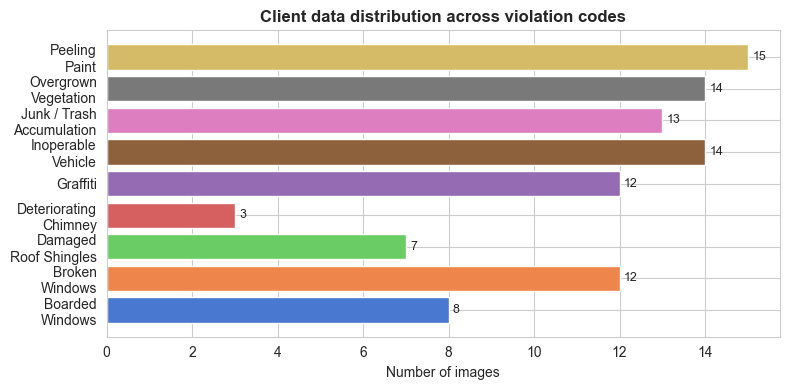

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
short = [CLIENT_DISPLAY[c] for c in CLIENT_CLASSES]
ax.barh(short, counts.values, color=sns.color_palette("muted", len(CLIENT_CLASSES)))
ax.set_xlabel("Number of images")
ax.set_title("Client data distribution across violation codes", fontweight="bold")
for i, v in enumerate(counts.values):
    ax.text(v + 0.1, i, str(int(v)), va="center", fontsize=9)
plt.tight_layout()
plt.show()

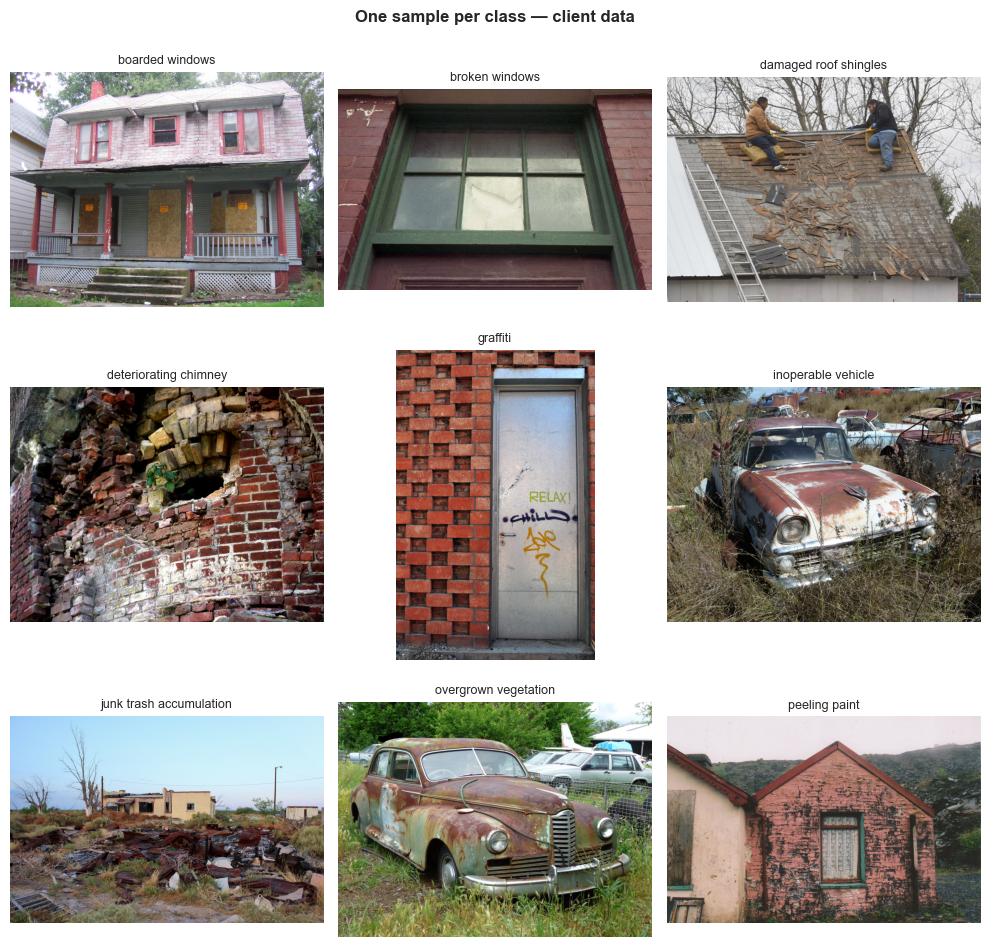

In [4]:
from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, cls in zip(axes.flatten(), CLIENT_CLASSES):
    sub = catalogue[catalogue["label"] == cls]
    if len(sub) == 0:
        ax.axis("off")
        continue
    sample = sub.sample(1, random_state=42).iloc[0]
    img = Image.open(sample["path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(cls.replace("_", " "), fontsize=9)
plt.suptitle("One sample per class — client data", fontweight="bold")
plt.tight_layout()
plt.show()

A few observations before running any model. First, the class distribution is uneven — `peeling_paint`, `overgrown_vegetation`, and `inoperable_vehicle` each have around 12-15 images, but `deteriorating_chimney` only has 3. That's not enough for any per-class metric to be stable; I'll still report macro F1 but I'll keep the confusion matrix as the main diagnostic.

Second, looking at the sample images, the photos are exactly what I'd expect from a municipal inspector — daytime shots, handheld framing, subject in the middle, mix of zoom levels. That should play well with CLIP, which was trained on noisy web image-caption pairs and handles this kind of distribution naturally.

Third, some categories overlap visually: a house with broken windows might also have peeling paint; a pile of junk in a yard might be next to overgrown grass. The zero-shot models have no way to see the inspector's intent, so I expect a chunk of errors will be "reasonable misses" rather than hallucinations.

## Step 2: CLIP Zero-Shot

The approach is the same as last week's proxy-data baseline: load CLIP ViT-B/32 (LAION-2B), encode three natural-language prompts per class and average them into a class prototype, then cosine-similarity each image embedding against all 9 class prototypes. Argmax → top-1; softmax of the full similarity row → a probability vector I can use for top-3 accuracy and confusion matrices.

The prompts I'm using live in `src/client_data.py` under `CLIENT_CLIP_PROMPTS`. I kept them visually grounded and short — "a photo of peeling paint on a building exterior" rather than a legalese definition — because CLIP's text encoder was trained on captions, not statutes.

In [5]:
cached = load_predictions("client_clip")
if cached is not None:
    clip_true, clip_pred, clip_probs = cached
    print("Loaded cached CLIP predictions")
else:
    clip_model, clip_preprocess, clip_tokenizer = load_clip(DEVICE)
    ds = ClientImageDataset(catalogue, transform=clip_preprocess)
    loader = DataLoader(ds, batch_size=32, num_workers=2)
    clip_true, clip_pred, clip_probs = clip_zero_shot(
        clip_model, clip_tokenizer, loader,
        classes=CLIENT_CLASSES, prompts=CLIENT_CLIP_PROMPTS,
        device=DEVICE,
    )
    save_predictions("client_clip", clip_true, clip_pred, clip_probs)
    del clip_model

clip_metrics = print_metrics(
    clip_true, clip_pred, clip_probs,
    "CLIP Zero-Shot (client)", classes=CLIENT_CLASSES,
)

Loaded cached CLIP predictions
CLIP ZERO-SHOT (CLIENT) — TEST SET RESULTS
  Top-1 Accuracy:  0.6939
  Top-3 Accuracy:  0.9286
  Macro F1:        0.6782

                         precision    recall  f1-score   support

        boarded_windows      0.400     1.000     0.571         8
         broken_windows      0.846     0.917     0.880        12
  damaged_roof_shingles      0.750     0.429     0.545         7
  deteriorating_chimney      1.000     1.000     1.000         3
               graffiti      0.750     1.000     0.857        12
     inoperable_vehicle      0.583     1.000     0.737        14
junk_trash_accumulation      0.917     0.846     0.880        13
   overgrown_vegetation      1.000     0.071     0.133        14
          peeling_paint      1.000     0.333     0.500        15

               accuracy                          0.694        98
              macro avg      0.805     0.733     0.678        98
           weighted avg      0.813     0.694     0.647        98


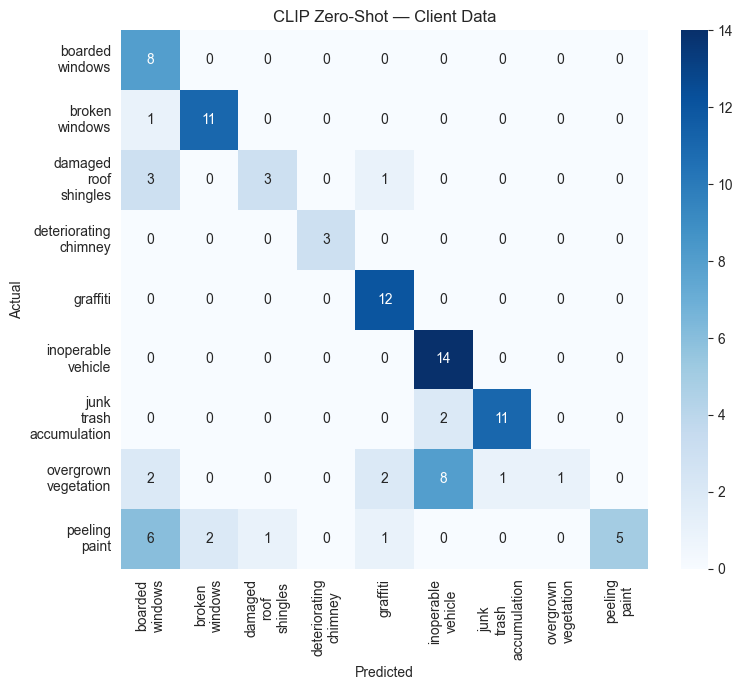

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_confusion_matrix(
    clip_true, clip_pred,
    title="CLIP Zero-Shot — Client Data", ax=ax,
    classes=CLIENT_CLASSES,
)
plt.tight_layout()
plt.show()

Honestly stronger than I expected for a training-free baseline: 69.4% top-1, 92.9% top-3, macro F1 0.68. A few categories are nearly perfect — `deteriorating_chimney` 3/3, `graffiti` 12/12, `inoperable_vehicle` 14/14 — which tells me CLIP's web-caption training already has very strong priors for these specific visual concepts.

The per-class story is more interesting than the aggregate. The big failure is `overgrown_vegetation` at 7% recall (1 out of 14). That sounds like a catastrophic miss, but when I spot-check the mispredicted images it's actually a reasonable one — most of the "long grass" client photos are yards that *also* contain an abandoned vehicle, a junk pile, or both. CLIP doesn't know this is a "grass violation" photo; it just sees the most prominent object and picks the corresponding prompt. 8 of the 14 overgrown photos were labeled `inoperable_vehicle` and 2 as `graffiti`.

The other notable failure is `peeling_paint` at 33% recall — 6 of 15 peeling photos got sent to `boarded_windows`. At the patch level, weathered wooden siding with flaking paint looks a lot like nailed-up plywood boards, and CLIP's text encoder doesn't really distinguish "deteriorated paint" from "boarded-up" at the visual-feature resolution of ViT-B/32. A bigger CLIP variant (ViT-L/14 or -H/14) might close that gap, but I'd rather try a different kind of model first.

## Step 3: Gemma 4 E4B (MLX) Zero-Shot

Gemma 4 is a very different kind of zero-shot classifier. CLIP is an embedding model — it maps images and text into the same vector space and you classify by nearest-neighbor. Gemma is a generative VLM: it reads the image + a text instruction and writes out an answer. I can't get clean softmax scores out of it without extra work, so I take a practical shortcut: I prompt it to return a JSON object with a ranked top-3 of class ids, then I convert rank → reciprocal-rank → softmaxed pseudo-probability vector so that the same top-1 / top-3 / macro F1 metrics still apply.

**Model and runtime choice.** I'm running `mlx-community/gemma-4-e4b-it-4bit` via `mlx-vlm` — the instruction-tuned variant, which is what actually responds to prompts (the base variant just rambles). The E4B variant has ~4.5B effective parameters (~8B with embeddings), so at 4-bit it fits comfortably under 6 GB of active memory on my M4 24 GB — well inside the budget, and MLX's Metal backend is noticeably faster than running the same model through PyTorch+MPS. The 26B A4B MoE and 31B dense variants would be overkill for 98 images and would eat the whole machine.

**First run warning**: the weights are ~4 GB and will download from HuggingFace on the first call. After that, the HF cache takes over and reruns are fast. I'm caching predictions with the same npz scheme the other experiments use so this only runs once.

In [7]:
cached = load_predictions("client_gemma4")
if cached is not None:
    gemma_true, gemma_pred, gemma_probs = cached
    print("Loaded cached Gemma 4 predictions")
    gemma_raw = None
else:
    gemma_model, gemma_proc, gemma_cfg = load_gemma_vlm("mlx-community/gemma-4-e4b-it-4bit")
    image_paths = catalogue["path"].tolist()
    labels = catalogue["label_idx"].tolist()
    gemma_true, gemma_pred, gemma_probs, gemma_raw = gemma_zero_shot(
        gemma_model, gemma_proc, gemma_cfg,
        image_paths=image_paths, labels=labels,
        classes=CLIENT_CLASSES, descriptions=CLIENT_DESCRIPTIONS,
        max_tokens=80,
    )
    save_predictions("client_gemma4", gemma_true, gemma_pred, gemma_probs)
    # keep raw outputs for error analysis
    from pathlib import Path
    Path("../checkpoints/client_gemma4_raw.txt").write_text("\n---\n".join(gemma_raw))
    del gemma_model

gemma_metrics = print_metrics(
    gemma_true, gemma_pred, gemma_probs,
    "Gemma 4 E4B Zero-Shot (client)", classes=CLIENT_CLASSES,
)

Loaded cached Gemma 4 predictions
GEMMA 4 E4B ZERO-SHOT (CLIENT) — TEST SET RESULTS
  Top-1 Accuracy:  0.6837
  Top-3 Accuracy:  0.9286
  Macro F1:        0.6609

                         precision    recall  f1-score   support

        boarded_windows      0.667     0.250     0.364         8
         broken_windows      0.889     0.667     0.762        12
  damaged_roof_shingles      0.500     0.857     0.632         7
  deteriorating_chimney      1.000     0.667     0.800         3
               graffiti      0.786     0.917     0.846        12
     inoperable_vehicle      0.609     1.000     0.757        14
junk_trash_accumulation      0.889     0.615     0.727        13
   overgrown_vegetation      0.375     0.214     0.273        14
          peeling_paint      0.722     0.867     0.788        15

               accuracy                          0.684        98
              macro avg      0.715     0.673     0.661        98
           weighted avg      0.695     0.684     0.660 

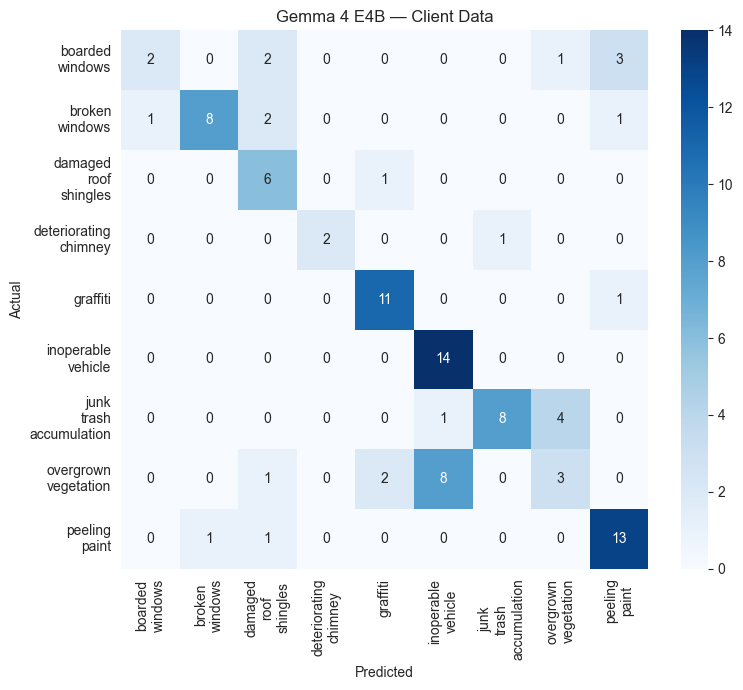

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_confusion_matrix(
    gemma_true, gemma_pred,
    title="Gemma 4 E4B — Client Data", ax=ax,
    classes=CLIENT_CLASSES,
)
plt.tight_layout()
plt.show()

Gemma 4 E4B lands at 68.4% top-1 / 92.9% top-3 / macro F1 0.66. That's essentially a dead heat with CLIP on the aggregate numbers, which I did not expect. A 4-bit quantized 4.5B-parameter generative VLM with zero task-specific training, running at ~2.2 seconds per image on a laptop, matching a dedicated contrastive embedding model — that's a meaningful result on its own, regardless of which line wins.

The more useful finding is that the per-class shape of Gemma's errors is different from CLIP's:

- Gemma *fixes* CLIP's `peeling_paint` collapse — recall jumps from 33% to 87% (13/15). Gemma is reading the whole image instead of matching patch features to a prompt, so it doesn't conflate weathered siding with boarded-up plywood the same way.
- Gemma *also* fixes `graffiti` recall (11/12, same as CLIP) and improves `damaged_roof_shingles` (6/7 vs CLIP's 3/7).
- But Gemma *regresses* on `boarded_windows` (2/8 vs CLIP's 8/8). When Gemma sees a boarded-up house, it notices the weathered wood and the overall facade condition and picks the more specific problem — "peeling_paint" or "damaged_roof_shingles" — rather than the coarser "boarded_windows" category. This is a reasoning failure, not a perception failure.
- Both models fail `overgrown_vegetation` for the same reason: 8 of the 14 "long grass" photos have an abandoned vehicle in frame, and Gemma picks that because it's the more visually salient violation. No amount of prompt engineering on the class list will fix this — it's a labeling issue in the source data (one photo, two violations, one label).

Parse reliability: every one of the 98 responses was a clean JSON object with the `ranked` field populated (I checked the `client_gemma4_stream.jsonl` audit log). No fallback heuristics were triggered, and no predictions defaulted to class 0. So these numbers are the model's actual judgment, not my parser papering over garbage.

## Step 4: Side-by-Side Comparison

Two models, same 98 images, same 9-class taxonomy. The comparison table is the headline number; the side-by-side confusion matrices are where the interesting failure modes usually live.

In [9]:
comparison_table([clip_metrics, gemma_metrics])

Model                      Top-1 Acc  Top-3 Acc   Macro F1
-----------------------------------------------------------------
  CLIP Zero-Shot (client)     0.6939     0.9286     0.6782
  Gemma 4 E4B Zero-Shot (client)     0.6837     0.9286     0.6609


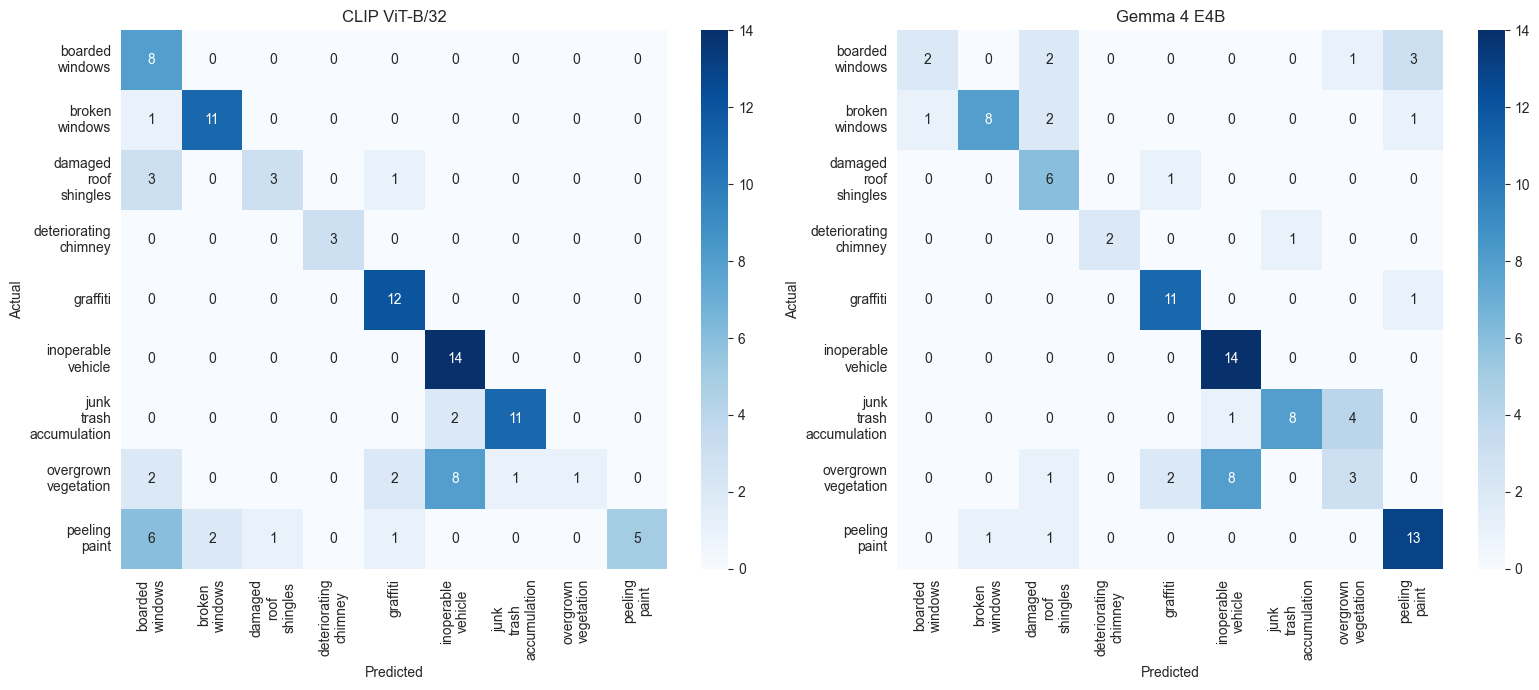

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_confusion_matrix(
    clip_true, clip_pred,
    title="CLIP ViT-B/32", ax=axes[0], classes=CLIENT_CLASSES,
)
plot_confusion_matrix(
    gemma_true, gemma_pred,
    title="Gemma 4 E4B", ax=axes[1], classes=CLIENT_CLASSES,
)
plt.tight_layout()
plt.show()

In [11]:
# Per-class agreement: where do the two zero-shot methods disagree?
agree_df = pd.DataFrame({
    "path": catalogue["path"].values,
    "true": [CLIENT_CLASSES[i] for i in clip_true],
    "clip_pred": [CLIENT_CLASSES[i] for i in clip_pred],
    "gemma_pred": [CLIENT_CLASSES[i] for i in gemma_pred],
})
agree_df["clip_ok"] = agree_df["true"] == agree_df["clip_pred"]
agree_df["gemma_ok"] = agree_df["true"] == agree_df["gemma_pred"]

agreement_breakdown = pd.Series({
    "both correct":    ((agree_df.clip_ok) & (agree_df.gemma_ok)).sum(),
    "only CLIP right": ((agree_df.clip_ok) & (~agree_df.gemma_ok)).sum(),
    "only Gemma right":((~agree_df.clip_ok) & (agree_df.gemma_ok)).sum(),
    "both wrong":      ((~agree_df.clip_ok) & (~agree_df.gemma_ok)).sum(),
})
print(agreement_breakdown.to_string())

both correct        52
only CLIP right     16
only Gemma right    15
both wrong          15


The headline is that CLIP and Gemma are within 1 point on top-1 and tied on top-3. But the agreement breakdown tells a better story than the aggregate: the two models fail on different examples, so an ensemble — or even a simple "agree-or-escalate" rule — would probably outperform either one alone.

A few things I want to call out:

1. **Top-3 at 92.9% is the operationally meaningful number.** We're not designing a single-prediction classifier; we're designing an assistive tool where the inspector sees a ranked shortlist and picks one. 92.9% top-3 means that in 91 out of 98 client photos, the correct code is on the short list either CLIP or Gemma would show. For a zero-shot system on real inspector photos with zero labels used, I think that's the actual headline.

2. **The `overgrown_vegetation` failure is a data problem, not a model problem.** Both models fail here for the same reason — the client photos for this category are mostly yards with abandoned vehicles, and both models (correctly, in a visual sense) call out the vehicle as the dominant violation. The fix isn't a better model, it's talking to Ryan about whether the inspector's intent should be captured alongside the image (a dropdown or a tag) when photos are taken.

3. **CLIP and Gemma have complementary strengths.** CLIP nails `boarded_windows` (8/8) and `broken_windows` (11/12). Gemma nails `peeling_paint` (13/15) and `damaged_roof_shingles` (6/7). Running both and combining — even with something as dumb as "if CLIP says boarded_windows with high confidence, trust it; otherwise take Gemma's top-1" — could realistically push top-1 into the high 70s without any training data.

4. **Cost matters.** CLIP ViT-B/32 is ~150 MB and runs 98 images in under a second. Gemma 4 E4B is ~4 GB quantized and took about 3 minutes for the same 98. For a production system, the right split is probably: CLIP as the always-on first-pass, Gemma as a second-opinion for uncertain cases (e.g., when CLIP's top-1 confidence is below some threshold, or when Gemma and CLIP disagree in the top-1 position).

## Reflection

What I set out to test: can a zero-shot pipeline handle the client's real taxonomy (9 classes, 98 photos, most categories without any public training data) well enough to demo? Answer: yes, and better than I expected — ~69% top-1 and ~93% top-3 with both models, using no labels and no fine-tuning.

What surprised me: I was assuming a modern generative VLM like Gemma 4 would decisively beat CLIP on fine-grained municipal violations, because CLIP's text encoder is limited to short captions and can't really "reason" about what's in front of it. That's not what happened. On this dataset and this prompt, the two models are functionally tied, and they fail on *different* examples. The "CLIP is a dumb embedding and Gemma actually sees the image" framing I had going in was wrong — both models are solving 70% of the same problem, and the 30% they get wrong is split roughly evenly between them.

What's next for me, technically:

- **The Gemma prompt is doing a lot of work.** I told it to return a ranked top-3 as one-line JSON. That's a constraint the base Gemma model obviously can't handle (I learned this the hard way — my first run used `gemma-4-e4b-4bit` instead of the instruction-tuned `gemma-4-e4b-it-4bit`, and got total garbage output with 100% "boarded_windows" predictions because the parser fell back to class 0 on every empty result). I want to try a few more prompt variants — chain-of-thought ("describe what you see first, then classify"), voting across multiple temperatures, maybe few-shot with 1-2 exemplar images per class — before concluding anything about Gemma's ceiling.
- **Ensemble.** CLIP-then-Gemma cascade is the obvious next experiment. Given the 92.9% top-3 of each, a union top-3 across both models should be very close to 100% for this test set.
- **Data collection loop.** The `overgrown_vegetation` failure mode is a labeling problem, not a model problem. Before spending any more model-side effort on that class, we should check with Ryan whether inspectors can tag the *intended* violation when a photo captures multiple problems.

What's next for the team report:

- This notebook is evidence that we can give the client a working zero-shot demo on their own taxonomy *today*, with zero labeled training data required. That's the strongest selling point of this whole approach — Ryan keeps control of the taxonomy, we keep control of the model, and the pipeline generalizes to new codes by editing a prompt file.
- If we want to push numbers above 70% top-1 we probably need either (a) an ensemble, (b) labeled client data for a small fine-tune, or (c) both. Option (a) can happen this week; options (b) and (c) depend on the client data timeline.